# Fuerza Bruta y Complejidad Computacional


**Propósito:** comprender, desde la teoría y la práctica, qué son los algoritmos de **fuerza bruta**, cómo se analizan en tiempo y espacio, y cómo se relacionan con la **complejidad computacional** (clases P y NP), con experimentos reproducibles en Python.

## Objetivos

1. Definir y caracterizar el enfoque de fuerza bruta y sus variantes (enumeración exhaustiva, generate-and-test, búsqueda ciega).
2. Repasar la notación asintótica (O, Θ, Ω), los casos peor/mejor/promedio, y las clases P / NP.
3. Explorar la explosión combinatoria con ejemplos clásicos: búsqueda lineal, ataque por diccionario, búsqueda de patrón, subset-sum y TSP.
4. Medir tiempos empíricamente y visualizar tasas de crecimiento (log, lineal, cuadrática, exponencial, factorial).
5. Comparar fuerza bruta pura contra una primera poda (branch-and-bound), como puente hacia el backtracking.
6. Discutir cuándo un método de fuerza bruta es aceptable, y qué alternativas existen.

> 📎 **Material de apoyo (diapositivas):** [Algoritmos de Fuerza Bruta — Fundamentos, Análisis y Aplicaciones (PDF)](_static/unidad2/FuerzaBruta_Slides.pdf)


## 1. ¿Qué es un algoritmo de fuerza bruta?

Un **algoritmo de fuerza bruta** intenta resolver un problema **probando sistemáticamente** todas las posibilidades o construyendo todas las soluciones candidatas y verificándolas con un **test**. Es directo, fácil de implementar y **correcto** si explora el espacio completo, pero suele ser **ineficiente** cuando el número de combinaciones crece rápidamente.

### Rasgos clave
- **Enumeración exhaustiva**: lista o genera todas las configuraciones posibles.
- **Generate & Test**: para cada candidato, evalúa si cumple la condición.
- **Ceguera**: carece de conocimiento específico del problema que guíe la búsqueda (a diferencia de heurísticas, poda o programación dinámica).
- **Complejidad alta**: a menudo exponencial o factorial en el tamaño de la entrada.
- **Ventajas**: simplicidad, facilidad de verificar correctitud, útil como línea base o cuando el espacio es pequeño (n ≤ 20).
- **Desventajas**: escala muy mal; puede ser inviable incluso para entradas moderadas.

> Regla mental: si el problema requiere **probar todas las combinaciones** y **no hay** estructura que aprovechar, probablemente sea fuerza bruta.


## 2. Complejidad computacional en contexto

### 2.1 Modelo de costo
- **Operación básica**: asumimos costo constante para acceso a arreglo, comparaciones simples, suma/resta, etc.
- **Abstracciones**: ignoramos constantes y detalles de hardware para enfocarnos en cómo *crece* el tiempo/espacio con el tamaño de entrada `n`.

### 2.2 Notación asintótica
- **O(f(n))** (cota superior): el algoritmo no tarda más que una constante por `f(n)` para `n` suficientemente grande.
- **Ω(f(n))** (cota inferior): el algoritmo tarda al menos una constante por `f(n)`.
- **Θ(f(n))** (cota ajustada): acotado superior e inferior por `f(n)`.

### 2.3 Casos de análisis
- **Peor caso**: garantiza rendimiento en el escenario más desfavorable.
- **Mejor caso**: útil para entender límites inferiores, rara vez suficiente por sí solo.
- **Caso promedio**: requiere un modelo probabilístico de entradas.

### 2.4 Clases de complejidad (visión de alto nivel)
- **P**: problemas resolubles en tiempo polinomial (≈ "eficientes").
- **NP**: soluciones verificables en tiempo polinomial (no necesariamente encontrables rápido).
- **NP-completo**: los problemas más "difíciles" de NP; si resuelves uno en P, entonces P = NP.
- **Exponencial / Factorial**: tiempos del tipo `c^n` o `n!`, típicos de fuerza bruta pura.


In [1]:
# Utilidades compartidas para medir y graficar tiempos (se usan en todos los ejemplos de este notebook)
import time
from typing import Callable, Tuple, Any

def timeit(f: Callable, *args, **kwargs) -> Tuple[float, Any]:
    """Ejecuta f(*args, **kwargs) y devuelve (tiempo_en_segundos, resultado)."""
    t0 = time.perf_counter()
    out = f(*args, **kwargs)
    t1 = time.perf_counter()
    return (t1 - t0), out

def plot_growth(x, ys, labels=None, x_label="n", y_label="Tiempo (s)", title="Escalado empírico", logy=True):
    """Grafica una o varias series (ys puede ser una lista de listas) contra x."""
    import matplotlib.pyplot as plt
    plt.figure()
    if isinstance(ys[0], (list, tuple)):
        for serie, label in zip(ys, labels or [None] * len(ys)):
            plt.plot(x, serie, marker="o", label=label)
        if labels:
            plt.legend()
    else:
        plt.plot(x, ys, marker="o")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    if logy:
        plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.show()

## 3. ¿Cómo crecen los tiempos?

Comparamos funciones típicas de complejidad: `log n`, `n`, `n log n`, `n^2`, `2^n`, `n!`. Observa cómo las exponenciales/factoriales **dominan** rápidamente.


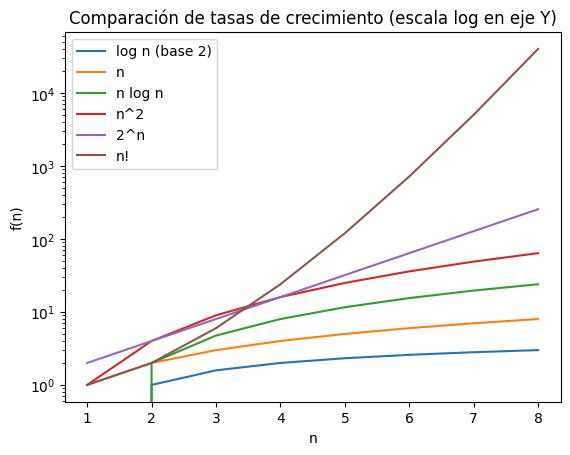

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

ns = np.arange(1, 9)  # n pequeño para que n! no desborde
logn = np.log2(ns)
n = ns
nlogn = ns * np.log2(ns)
n2 = ns**2
two_n = 2**ns
fact = np.array([math.factorial(int(k)) for k in ns])

plt.figure()
plt.plot(ns, logn, label='log n (base 2)')
plt.plot(ns, n, label='n')
plt.plot(ns, nlogn, label='n log n')
plt.plot(ns, n2, label='n^2')
plt.plot(ns, two_n, label='2^n')
plt.plot(ns, fact, label='n!')
plt.yscale('log')
plt.xlabel('n')
plt.ylabel('f(n)')
plt.title('Comparación de tasas de crecimiento (escala log en eje Y)')
plt.legend()
plt.show()

## 4. Patrones y familias de fuerza bruta

1. **Búsqueda lineal (secuencial)** sobre una lista: prueba cada elemento hasta encontrar la coincidencia. `Θ(n)`.
2. **Enumeración de combinaciones/permutaciones** con `itertools`: tamaño del espacio ≈ `C(n,k)` o `n!`.
3. **Generate-and-test**: genera candidatos y valida con un predicado.
4. **Búsqueda ciega en grafos** (BFS/DFS sin heurística específica). *Nota:* BFS/DFS no son "fuerza bruta" per se, pero si exploran exhaustivamente sin poda, se comportan como tal.
5. **Backtracking sin poda** ≈ fuerza bruta; con poda ya introduce inteligencia (no es "pura") — lo verás en la siguiente sección de esta unidad.


## 5. Ejemplo 1 — Búsqueda lineal vs. binaria

- **Lineal (fuerza bruta)**: recorre todos los elementos hasta hallar el objetivo. `Θ(n)` en peor caso.
- **Binaria (optimizada)**: requiere datos ordenados; divide y vencerás. `Θ(log n)`.


In [3]:
def linear_search(arr, x):
    for i, v in enumerate(arr):
        if v == x:
            return i
    return -1

def binary_search(arr, x):
    lo, hi = 0, len(arr) - 1
    while lo <= hi:
        mid = (lo + hi) // 2
        if arr[mid] == x:
            return mid
        if arr[mid] < x:
            lo = mid + 1
        else:
            hi = mid - 1
    return -1

for n in [10_000, 100_000, 500_000]:
    arr = list(range(n))
    x = n - 1  # peor caso para la lineal (el ultimo elemento)
    t_lineal, _ = timeit(linear_search, arr, x)
    t_binaria, _ = timeit(binary_search, arr, x)
    print(f"n={n:>7} | lineal ~{t_lineal:.6f}s | binaria ~{t_binaria:.6f}s")

n=  10000 | lineal ~0.000327s | binaria ~0.000007s
n= 100000 | lineal ~0.002168s | binaria ~0.000007s
n= 500000 | lineal ~0.014696s | binaria ~0.000015s


## 6. Ejemplo 2 — Búsqueda de patrón: método ingenuo vs. optimizado

El método **naive** compara el patrón `P` (longitud `m`) en cada posición del texto `T` (longitud `n`), con salida temprana en cuanto un carácter no coincide ⇒ `O(n·m)` en el peor caso. Lo comparamos contra `str.find` (que internamente usa un algoritmo más eficiente).


n= 10000 | naive=0.000549s  str.find=0.000008s
n= 20000 | naive=0.001053s  str.find=0.000012s
n= 40000 | naive=0.002088s  str.find=0.000023s
n= 80000 | naive=0.004602s  str.find=0.000049s


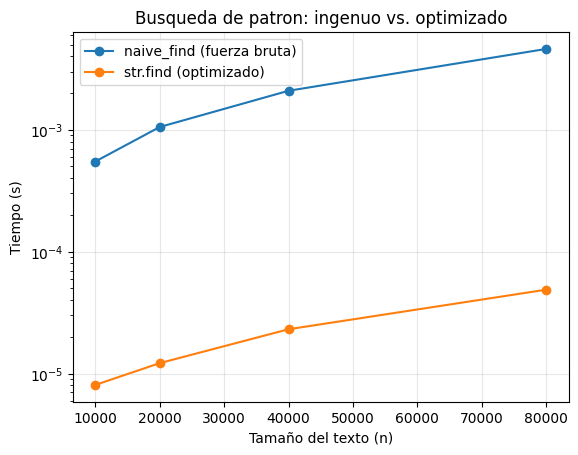

In [4]:
import random, string

def naive_find(text: str, pattern: str) -> int:
    n, m = len(text), len(pattern)
    if m == 0:
        return 0
    for i in range(n - m + 1):
        j = 0
        while j < m and text[i + j] == pattern[j]:
            j += 1
        if j == m:
            return i
    return -1

def bench_pattern(n_text: int, n_pat: int):
    text = "".join(random.choice(string.ascii_lowercase) for _ in range(n_text))
    pattern = "".join(random.choice(string.ascii_lowercase) for _ in range(n_pat))
    t_naive, _ = timeit(naive_find, text, pattern)
    t_builtin, _ = timeit(str.find, text, pattern)
    return t_naive, t_builtin

sizes = [10_000, 20_000, 40_000, 80_000]
naive_t, builtin_t = [], []
for s in sizes:
    t_na, t_bi = bench_pattern(s, 5)
    naive_t.append(t_na)
    builtin_t.append(t_bi)
    print(f"n={s:>6} | naive={t_na:.6f}s  str.find={t_bi:.6f}s")

plot_growth(sizes, [naive_t, builtin_t], labels=["naive_find (fuerza bruta)", "str.find (optimizado)"],
            x_label="Tamaño del texto (n)", title="Busqueda de patron: ingenuo vs. optimizado")

## 7. Ejemplo 3 — Explosión combinatoria: ataque por diccionario

Dado un alfabeto de tamaño `k` y una longitud objetivo `n`, existen `k^n` cadenas posibles. Probamos **todas** las combinaciones hasta encontrar el objetivo, y medimos cómo crece el tiempo con `n`.


target='cab' -> encontrada='cab', intentos=34, tiempo=0.000009s
n=1: 0.000003s  (espacio de busqueda = 5^1 = 5)
n=2: 0.000002s  (espacio de busqueda = 5^2 = 25)
n=3: 0.000007s  (espacio de busqueda = 5^3 = 125)
n=4: 0.000011s  (espacio de busqueda = 5^4 = 625)
n=5: 0.000155s  (espacio de busqueda = 5^5 = 3125)
n=6: 0.000049s  (espacio de busqueda = 5^6 = 15625)


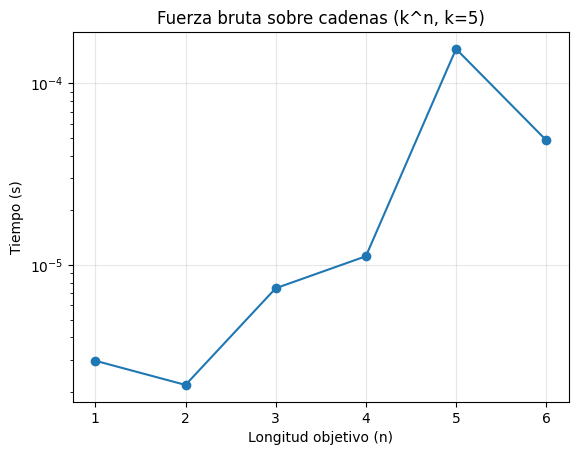

In [5]:
from itertools import product

def brute_force_match(target: str, alphabet: str):
    """Prueba cadenas en orden lexicografico. Devuelve (intentos, cadena_encontrada)."""
    n = len(target)
    attempts = 0
    for tup in product(alphabet, repeat=n):
        attempts += 1
        cand = "".join(tup)
        if cand == target:
            return attempts, cand
    return attempts, ""

# Prueba rapida
alphabet = "abcd"
target = "cab"
dt, (attempts, encontrada) = timeit(brute_force_match, target, alphabet)
print(f"target='{target}' -> encontrada='{encontrada}', intentos={attempts}, tiempo={dt:.6f}s")

# Crecimiento con la longitud n (alfabeto fijo de 5 letras: k=5)
def runner_len(n: int) -> float:
    alpha = "abcde"
    obj = "".join(random.choice(alpha) for _ in range(n))
    dt, _ = timeit(brute_force_match, obj, alpha)
    return dt

lens = list(range(1, 7))  # k^n con k=5: hasta 5^6 = 15625
times = [runner_len(n) for n in lens]
for n, t in zip(lens, times):
    print(f"n={n}: {t:.6f}s  (espacio de busqueda = 5^{n} = {5**n})")

plot_growth(lens, times, x_label="Longitud objetivo (n)", title="Fuerza bruta sobre cadenas (k^n, k=5)")

## 8. Ejemplo 4 — Subset Sum: fuerza bruta vs. una primera poda

**Subset Sum**: dado un conjunto de enteros y un objetivo `T`, ¿existe un subconjunto que sume exactamente `T`?

- **Fuerza bruta**: prueba las `2^n` máscaras de bits posibles.
- **Con poda (branch-and-bound)**: si la suma parcial ya supera `T` (con números no negativos), se corta esa rama sin seguir explorando — es, en esencia, un backtracking con una condición de poda. Esta comparación es el puente hacia la sección de **Backtracking** de esta unidad.


In [6]:
def subset_sum_bruteforce(arr, target):
    n = len(arr)
    for mask in range(1 << n):
        s = 0
        for i in range(n):
            if mask & (1 << i):
                s += arr[i]
        if s == target:
            return True
    return False

def subset_sum_bnb(arr, target):
    arr_sorted = sorted(arr, reverse=True)
    n = len(arr_sorted)
    def dfs(i, current):
        if current == target:
            return True
        if current > target:      # <- poda: ya nos pasamos, no seguimos por esta rama
            return False
        if i == n:
            return False
        if dfs(i + 1, current + arr_sorted[i]):
            return True
        return dfs(i + 1, current)
    return dfs(0, 0)

# Correctitud
arr = [3, 34, 4, 12, 5, 2]
T = 9
print("Fuerza bruta:", subset_sum_bruteforce(arr, T))
print("Con poda    :", subset_sum_bnb(arr, T))

Fuerza bruta: True
Con poda    : True


n=10 | fuerza bruta=0.000054s | con poda=0.000006s
n=12 | fuerza bruta=0.000097s | con poda=0.000004s
n=14 | fuerza bruta=0.000175s | con poda=0.000008s
n=16 | fuerza bruta=0.000164s | con poda=0.000002s
n=18 | fuerza bruta=0.000912s | con poda=0.000004s
n=20 | fuerza bruta=0.000332s | con poda=0.000003s
n=22 | fuerza bruta=0.002909s | con poda=0.000007s


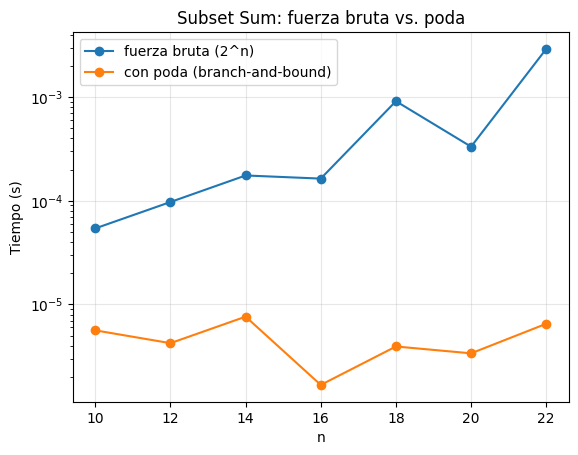

In [7]:
def make_instance(n, seed=42):
    rnd = random.Random(seed + n)
    nums = [rnd.randint(1, 50) for _ in range(n)]
    target = sum(nums) // 2
    return nums, target

ns = list(range(10, 23, 2))  # 2^22 ya es notable para la fuerza bruta pura
t_brute, t_bnb = [], []
for n in ns:
    nums, target = make_instance(n)
    dt1, _ = timeit(subset_sum_bruteforce, nums, target)
    dt2, _ = timeit(subset_sum_bnb, nums, target)
    t_brute.append(dt1)
    t_bnb.append(dt2)
    print(f"n={n:>2} | fuerza bruta={dt1:.6f}s | con poda={dt2:.6f}s")

plot_growth(ns, [t_brute, t_bnb], labels=["fuerza bruta (2^n)", "con poda (branch-and-bound)"],
            x_label="n", title="Subset Sum: fuerza bruta vs. poda")

## 9. Ejemplo 5 — El problema del viajante (TSP) por fuerza bruta

Para `n` ciudades, fijando una ciudad de inicio, hay `(n-1)!` rutas posibles a explorar. Probamos todas para `n` pequeño y medimos el tiempo — el crecimiento factorial se nota de inmediato.


In [8]:
from itertools import permutations

def tsp_bruteforce(dist):
    n = dist.shape[0]
    best_cost = float("inf")
    best_path = ()
    nodes = list(range(1, n))  # fijamos la ciudad 0 como origen
    for perm in permutations(nodes):
        cost = 0.0
        prev = 0
        for v in perm:
            cost += dist[prev, v]
            prev = v
        cost += dist[prev, 0]  # cerrar el ciclo
        if cost < best_cost:
            best_cost = cost
            best_path = (0,) + perm + (0,)
    return best_cost, best_path

def make_tsp(n, seed=7):
    rnd = np.random.default_rng(seed + n)
    pts = rnd.random((n, 2))
    dist = np.sqrt(((pts[:, None, :] - pts[None, :, :]) ** 2).sum(axis=2))
    return dist

for n in [6, 7, 8]:  # 5!=120, 6!=720, 7!=5040 rutas
    D = make_tsp(n)
    dt, (cost, path) = timeit(tsp_bruteforce, D)
    print(f"n={n} | tiempo={dt:.4f}s | costo={cost:.4f} | ruta={path}")

n=6 | tiempo=0.0001s | costo=3.0154 | ruta=(0, 4, 2, 5, 3, 1, 0)
n=7 | tiempo=0.0006s | costo=1.8777 | ruta=(0, 3, 1, 6, 4, 2, 5, 0)
n=8 | tiempo=0.0048s | costo=2.7345 | ruta=(0, 5, 3, 2, 1, 7, 4, 6, 0)


## 10. Complejidad espacial, trade-offs y paralelización

- **Espacio**: la fuerza bruta suele usar poco espacio (se puede generar *on-the-fly* con iteradores), aunque puede crecer si memorizamos estados.
- **Tiempo vs. espacio**: a veces conviene gastar memoria para evitar repetir trabajo (tabulación, *caching*) — pero entonces deja de ser fuerza bruta pura.
- **Paralelización**: como cada candidato se evalúa de forma independiente, la fuerza bruta paraleliza bien (CPU/GPU/clúster). Aun así, la explosión combinatoria puede dominar igual.
- **Heurísticas y poda**: podar ramas imposibles o poco prometedoras, *branch & bound*, búsqueda informada — mejoran lo práctico, pero ya no es fuerza bruta "pura" (así empieza el backtracking).
- **Aleatoriedad**: *random restarts*, Monte Carlo, Las Vegas — reducen tiempos esperados, sin garantías deterministas de peor caso.


## 11. ¿Cuándo sí usar fuerza bruta?

- El espacio de búsqueda es pequeño (o está acotado por requisitos de negocio).
- Necesitas una **línea base** para comparar contra optimizaciones más avanzadas.
- Requieres soluciones exactas y no hay métodos mejores para tu tamaño de `n`.
- Tienes recursos de cómputo masivos o ventanas de cálculo "offline".
- Forma parte de una solución híbrida (ej. fuerza bruta en la frontera de un algoritmo de divide y vencerás).

**Cuándo evitarla:** cuando `n` o el espacio de búsqueda crecen de forma que ningún multiplicador razonable de hardware alcanza (exponencial/factorial).


## 12. Retos y ejercicios

1. **Ataque por diccionario**: calcula el tiempo esperado de probar `A^L` combinaciones dado `X` intentos por segundo.
2. **Más poda en Subset Sum**: ordena por valor absoluto y corta ramas cuando la suma parcial ya excede el objetivo (con negativos incluidos).
3. **Naive vs. KMP**: implementa Knuth-Morris-Pratt y compáralo con `naive_find` en casos adversos (ver las diapositivas para la idea del algoritmo).
4. **TSP con `n=9..11`**: mide el tiempo y grafica `n` vs. tiempo. ¿Qué curva emerge?
5. **Paralelización**: usa `multiprocessing` para repartir el espacio de búsqueda de *subset-sum* entre varios procesos.
6. **Meet-in-the-middle**: guarda las sumas de la mitad del conjunto y compáralas contra la fuerza bruta pura — ¿cuánto mejora?


## Apéndice — Notas de implementación en Python

- `itertools.product`, `combinations`, `permutations` generan secuencias sin materializarlas (bueno en memoria).
- Usa `time.perf_counter()` para mediciones finas.
- Evita imprimir dentro de bucles de medición (afecta los tiempos).
- Para reproducibilidad, fija semillas de `random`.


## Referencias y lecturas sugeridas

- Cormen, Leiserson, Rivest, Stein. *Introduction to Algorithms* (CLRS) — capítulos de complejidad y problemas NP-completos.
- Kleinberg, Tardos. *Algorithm Design* — secciones sobre *brute force* y técnicas de diseño.
- Sipser. *Introduction to the Theory of Computation* — clases P y NP.
- Skiena. *The Algorithm Design Manual* — catálogo de problemas y enfoques prácticos.
- Garey, Johnson. *Computers and Intractability: A Guide to the Theory of NP-Completeness*.
- Dasgupta, Papadimitriou, Vazirani. *Algorithms*.
